# 실습 6: 쓸 수 있는 표 한 벌로 만들기
- 상황: 쓸 수 없는 열은 걸러냈는데 아직도 수백 개가 남았다
- 목표: 겹치는 센서를 묶고 관련 있는 것부터 남겨 정제본 한 벌을 만든다

## Step 0. 폴더와 노트북 만들고, 앞 실습 선별까지 다시 만들기

In [1]:
import pandas as pd

df = pd.read_csv("../../data/04_secom.csv")

sensor_cols = [c for c in df.columns if c.startswith("sensor_")]

rows = []
for c in sensor_cols:
    rows.append({
        "열 이름": c,
        "빈칸 비율(%)": df[c].isna().mean() * 100,
        "값 종류 수": df[c].nunique(),
        "표준편차": df[c].std(),
    })
diag = pd.DataFrame(rows)

# 세 조건 중 하나라도 걸리면 제외
제외_조건 = (diag["빈칸 비율(%)"] >= 50) | (diag["값 종류 수"] == 1) | (diag["표준편차"] <= 0.001)
제외_열 = diag.loc[제외_조건, "열 이름"].tolist()

# 원본 df는 그대로 두고, 제외 열만 뺀 df1을 새로 만든다
df1 = df.drop(columns=제외_열)

print("원본 df  - 행:", df.shape[0], " 열:", df.shape[1])
print("df1(정제) - 행:", df1.shape[0], " 열:", df1.shape[1])
print("제외된 열 개수:", len(제외_열))


원본 df  - 행: 1567  열: 592
df1(정제) - 행: 1567  열: 438
제외된 열 개수: 154


## Step 1. 겹친다는 게 무슨 뜻인지 눈으로 보기

### 두 센서를 나란히 그려본다
같은 것을 재고 있는 것처럼 보이는 짝이 있는지 확인한다.

고른 센서: sensor_177 / sensor_448


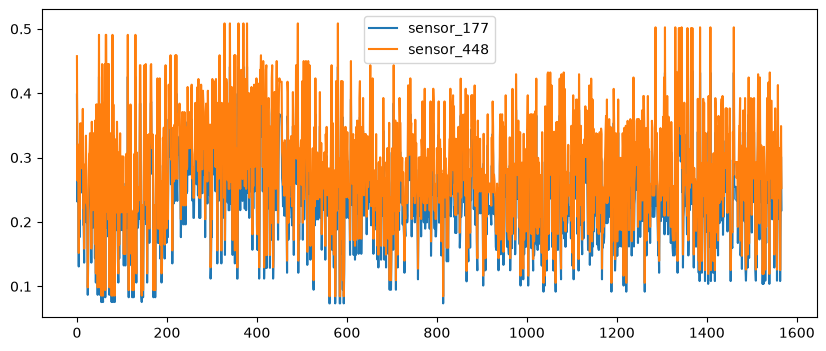

In [2]:
import matplotlib.pyplot as plt

# 실제로 겹치는 것으로 확인된 짝 (겹친다는 게 어떤 모양인지 보려고 미리 골라둔 두 개)
센서A = "sensor_177"
센서B = "sensor_448"

print("고른 센서:", 센서A, "/", 센서B)

# figure() - 그림판 하나를 편다. figsize 는 가로세로 크기(인치)
plt.figure(figsize=(10, 4))

# plot() - 값을 순서대로 선으로 잇는다. label 은 범례에 표시될 이름
plt.plot(df1[센서A].values, label=센서A)
plt.plot(df1[센서B].values, label=센서B)

# legend() - 어느 선이 무엇인지 알려주는 상자를 띄운다
plt.legend()
plt.show()

## Step 2. 겹치는 정도를 숫자로 재보기

### 용어 풀이 - 열끼리의 관계를 말할 때 쓰는 말

| 말 | 뜻 |
|---|---|
| 상관관계 (correlation) | 두 열이 얼마나 같이 움직이는지. -1에서 1 사이의 숫자로 잰다 |
| 상관계수 1에 가깝다 | 하나가 오르면 다른 하나도 같이 오른다 |
| 상관계수 -1에 가깝다 | 하나가 오르면 다른 하나는 내려간다. 이것도 "관계가 강한" 것이다 |
| 상관계수 0에 가깝다 | 서로 상관없이 따로 논다 |
| 다중공선성 | 같은 말을 하는 열이 여러 개 섞여 있는 상태. 같은 정보를 여러 번 세는 셈이 된다 |
| 표준화 (standardization) | 값을 "평균에서 표준편차 몇 배 떨어졌나"로 바꿔 적는 것. 단위가 다른 열을 같은 자로 재게 된다 |
| 변수 선택 (feature selection) | 쓸 열을 골라내는 일 전체. 오늘 하는 일에 붙은 이름 |
| 관련도 | 이 실습에서 쓰는 말. 그 센서와 불량 여부(1/0)의 상관계수 절댓값을 가리킨다 |

**상관관계가 높다고 원인은 아니다.**<br>
아이스크림 판매량과 익사 사고는 같이 오르내리지만, 아이스크림이 원인은 아니다.<br>
둘 다 여름이라 그렇다. 숫자가 높게 나와도 "관계가 있어 보인다"까지만 말한다.

In [3]:
# corr() - 두 열이 얼마나 같이 움직이는지 -1 ~ 1 사이 숫자로 계산한다
겹침정도 = df1[센서A].corr(df1[센서B])

print(센서A, "와", 센서B, "의 상관계수:", round(겹침정도, 4))

sensor_177 와 sensor_448 의 상관계수: 0.9999


### 문법 노트 - 열끼리 비교하기

| 쓴 것 | 하는 일 | 왜 여기 쓰나 |
|---|---|---|
| .corr(다른열) | 두 열의 상관계수를 계산 | 그림 없이 숫자 하나로 겹침 정도를 잰다 |
| .values | 표의 값만 꺼낸다 | 그래프를 그릴 때 줄 번호가 아니라 값만 필요해서 |
| plt.plot() | 값을 순서대로 선으로 잇는다 | 두 센서 모양을 겹쳐 보기 위해 |
| plt.legend() | 어느 선이 무엇인지 표시 | 선이 둘 이상이면 없으면 구분이 안 된다 |

**부호는 무시하고 크기만 본다.**<br>
-0.9 와 0.9 는 방향만 반대일 뿐 "강하게 붙어 다닌다"는 점에서 같다.<br>
그래서 겹치는 짝을 찾을 때는 절댓값을 쓴다.

## Step 3. 겹치는 짝 전부 찾아 대표만 남기기

In [4]:
# df1의 센서 열끼리 상관계수 전부 계산
sensor_cols_1 = [c for c in df1.columns if c.startswith("sensor_")]
상관표 = df1[sensor_cols_1].corr()

# 절댓값 0.9 이상인 짝 찾기 (같은 짝을 두 번 세지 않도록 위쪽 절반만 본다)
짝목록 = []
cols = 상관표.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        v = 상관표.iloc[i, j]
        if pd.notna(v) and abs(v) >= 0.9:
            짝목록.append({"열1": cols[i], "열2": cols[j], "상관계수": v})

짝표 = pd.DataFrame(짝목록)
짝표["절댓값"] = 짝표["상관계수"].abs()

print("절댓값 0.9 이상인 짝 개수:", len(짝표))

상위10 = 짝표.sort_values("절댓값", ascending=False).head(10)
print("\n상위 10쌍:")
display(상위10[["열1", "열2", "상관계수"]])

# 열별 빈칸 비율 (남길 쪽을 고르는 기준)
빈칸비율 = {c: df1[c].isna().mean() for c in sensor_cols_1}

# 짝마다 빈칸이 더 많은 쪽을 제외 대상으로 표시
제외열_집합 = set()
for _, row in 짝표.iterrows():
    c1, c2 = row["열1"], row["열2"]
    if 빈칸비율[c1] <= 빈칸비율[c2]:
        제외열_집합.add(c2)
    else:
        제외열_집합.add(c1)

df2 = df1.drop(columns=list(제외열_집합))

print("\n제외된(겹쳐서 뺀) 열 개수:", len(제외열_집합))
print("df1 열 수:", df1.shape[1])
print("df2 열 수:", df2.shape[1])


절댓값 0.9 이상인 짝 개수: 342

상위 10쌍:


,열1,열2,상관계수
23,sensor_075,sensor_210,1.0
26,sensor_075,sensor_479,1.0
25,sensor_075,sensor_348,1.0
24,sensor_075,sensor_343,1.0
285,sensor_343,sensor_348,1.0
176,sensor_210,sensor_348,1.0
177,sensor_210,sensor_479,1.0
166,sensor_207,sensor_210,1.0
175,sensor_210,sensor_343,1.0
168,sensor_207,sensor_348,1.0



제외된(겹쳐서 뺀) 열 개수: 190
df1 열 수: 438
df2 열 수: 248


## Step 4. 단위가 제각각이라는 것 확인하기

### 값의 크기가 열마다 얼마나 다른지 본다
같은 표에 들어 있어도 어떤 열은 0~1, 어떤 열은 수천일 수 있다.

In [5]:
# describe() - 열마다 개수, 평균, 표준편차, 최소, 최대 등을 한 번에 보여준다
# .T - 표를 가로세로 뒤집는다. 열이 많을 때는 세로로 봐야 읽힌다
# head() - 위에서 몇 줄만
df2.describe().T[["mean", "std", "min", "max"]].head(10)

,mean,std,min,max
sensor_001,3014.452896,73.621787,2743.2400,3356.3500
sensor_002,2495.850231,80.407705,2158.7500,2846.4400
sensor_003,2200.547318,29.513152,2060.6600,2315.2667
sensor_004,1396.376627,441.691640,0.0000,3715.0417
sensor_007,101.112908,6.237214,82.1311,129.2522
sensor_008,0.121822,0.008961,0.0000,0.1286
sensor_009,1.462862,0.073897,1.1910,1.6564
sensor_010,-0.000841,0.015116,-0.0534,0.0749
sensor_011,0.000146,0.009302,-0.0349,0.0530
sensor_012,0.964353,0.012452,0.6554,0.9848


In [6]:
# 센서 열들의 평균만 모아서 가장 작은 값과 가장 큰 값을 본다
평균들 = df2.describe().T["mean"]

# idxmin() / idxmax() - 가장 작은(큰) 값이 어느 줄인지 그 이름을 돌려준다
print("평균이 가장 작은 열:", 평균들.idxmin(), "→", 평균들.min())
print("평균이 가장 큰 열:", 평균들.idxmax(), "→", 평균들.max())

평균이 가장 작은 열: sensor_022 → -5618.393610223642
평균이 가장 큰 열: sensor_091 → 8827.536865303431


비교할 두 열: sensor_022 / sensor_091


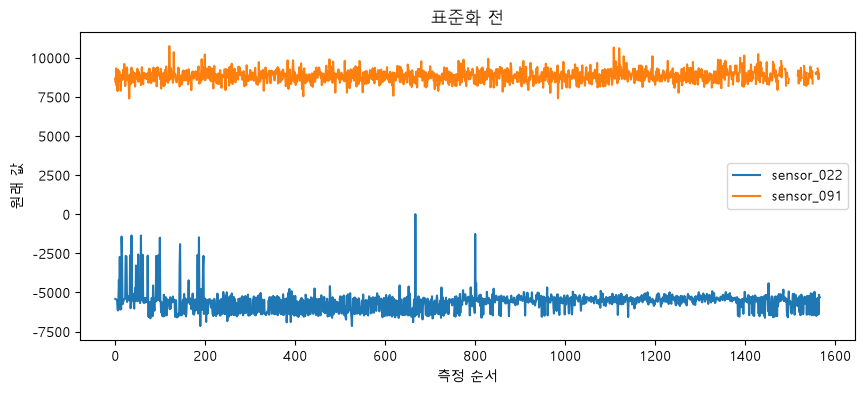

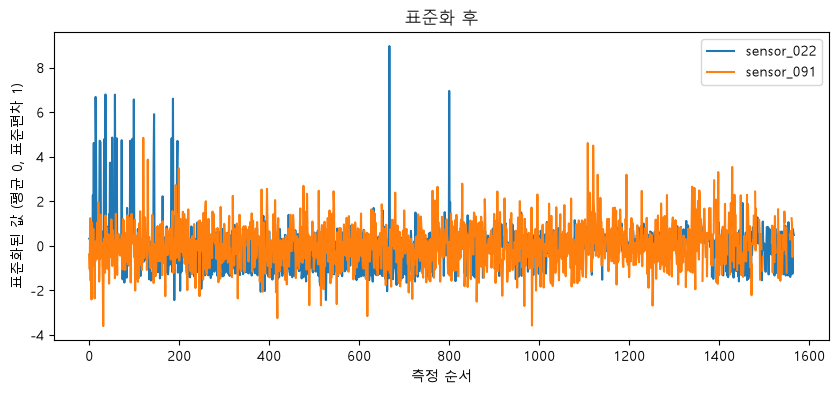

In [7]:
# 값의 크기(평균)가 가장 다른 두 열 (바로 위에서 찾은 것을 그대로 사용)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

열1 = 평균들.idxmin()
열2 = 평균들.idxmax()
print("비교할 두 열:", 열1, "/", 열2)

# 표준화: 평균 0, 표준편차 1로 바꾸기 (df2는 건드리지 않고 비교용으로만 새로 계산)
표준화_열1 = (df2[열1] - df2[열1].mean()) / df2[열1].std()
표준화_열2 = (df2[열2] - df2[열2].mean()) / df2[열2].std()

# 그림 1: 표준화 전
plt.figure(figsize=(10, 4))
plt.plot(df2[열1].values, label=열1)
plt.plot(df2[열2].values, label=열2)
plt.title("표준화 전")
plt.xlabel("측정 순서")
plt.ylabel("원래 값")
plt.legend()
plt.show()

# 그림 2: 표준화 후
plt.figure(figsize=(10, 4))
plt.plot(표준화_열1.values, label=열1)
plt.plot(표준화_열2.values, label=열2)
plt.title("표준화 후")
plt.xlabel("측정 순서")
plt.ylabel("표준화된 값 (평균 0, 표준편차 1)")
plt.legend()
plt.show()


sensor_163 df2에 있음: True
sensor_144 df2에 있음: True

sensor_163 - 평균: 4797.1546, 표준편차: 6553.5693
sensor_144 - 평균: 0.0042, 표준편차: 0.0013


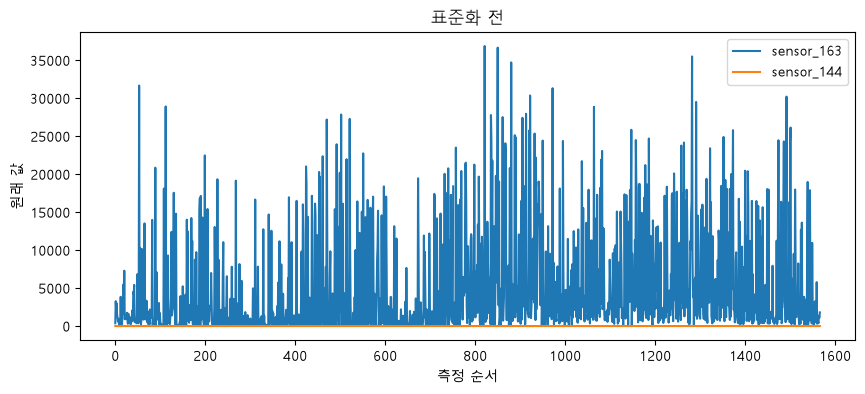

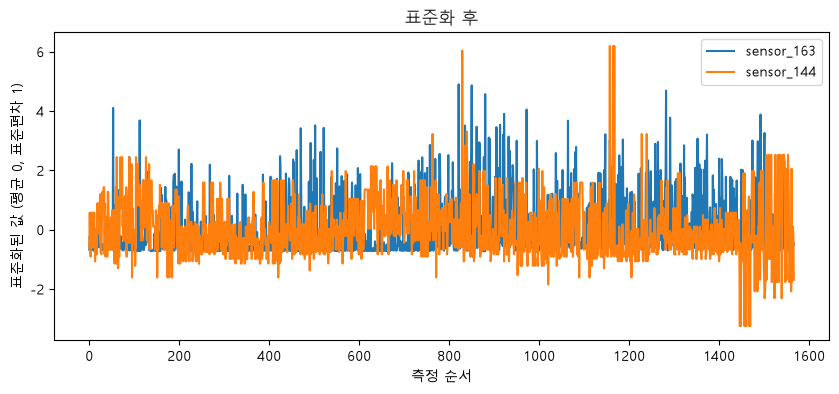

In [8]:
# 지정한 두 센서로 다시 비교 (sensor_163, sensor_144)
열1 = "sensor_163"
열2 = "sensor_144"

for c in [열1, 열2]:
    print(c, "df2에 있음:", c in df2.columns)

# 표준화: 평균 0, 표준편차 1로 바꾸기 (df2는 건드리지 않고 비교용으로만 새로 계산)
표준화_열1 = (df2[열1] - df2[열1].mean()) / df2[열1].std()
표준화_열2 = (df2[열2] - df2[열2].mean()) / df2[열2].std()

print(f"\n{열1} - 평균: {df2[열1].mean():.4f}, 표준편차: {df2[열1].std():.4f}")
print(f"{열2} - 평균: {df2[열2].mean():.4f}, 표준편차: {df2[열2].std():.4f}")

# 그림 1: 표준화 전
plt.figure(figsize=(10, 4))
plt.plot(df2[열1].values, label=열1)
plt.plot(df2[열2].values, label=열2)
plt.title("표준화 전")
plt.xlabel("측정 순서")
plt.ylabel("원래 값")
plt.legend()
plt.show()

# 그림 2: 표준화 후
plt.figure(figsize=(10, 4))
plt.plot(표준화_열1.values, label=열1)
plt.plot(표준화_열2.values, label=열2)
plt.title("표준화 후")
plt.xlabel("측정 순서")
plt.ylabel("표준화된 값 (평균 0, 표준편차 1)")
plt.legend()
plt.show()


## Step 5. 결과와 관련 있는 열부터 순서대로 보기

In [9]:
# 검사 결과(result) 열을 숫자로 바꾼 새 열 만들기 — 원래 열은 그대로 둠
df2["불량여부"] = (df2["result"] == "불량").astype(int)

print(df2[["result", "불량여부"]].head())
print("\n불량여부 값별 건수:")
print(df2["불량여부"].value_counts())

# df2의 센서 열 각각에 대해 불량여부와의 상관계수 계산
sensor_cols_2 = [c for c in df2.columns if c.startswith("sensor_")]

관련도 = []
for c in sensor_cols_2:
    r = df2[c].corr(df2["불량여부"])
    관련도.append({"센서 이름": c, "상관계수 절댓값": abs(r)})

rank_table = pd.DataFrame(관련도).sort_values("상관계수 절댓값", ascending=False).head(20).reset_index(drop=True)
rank_table


  result  불량여부
0     양품     0
1     양품     0
2     불량     1
3     양품     0
4     양품     0

불량여부 값별 건수:
불량여부
0    1463
1     104
Name: count, dtype: int64


C:\Users\LG\AppData\Local\Temp\ipykernel_3092\558009322.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df2["불량여부"] = (df2["result"] == "불량").astype(int)


,센서 이름,상관계수 절댓값
0,sensor_060,0.155796
1,sensor_104,0.151203
2,sensor_511,0.131593
3,sensor_432,0.120851
4,sensor_431,0.110067
5,sensor_022,0.108488
6,sensor_029,0.107252
7,sensor_130,0.103373
8,sensor_211,0.102545
9,sensor_164,0.100330


In [10]:
# rank_table 1등 열
일등_센서 = rank_table.loc[0, "센서 이름"]
print("rank_table 1등 열:", 일등_센서)

# result(양품/불량)별로 그 열의 평균값 비교
그룹별_평균 = df2.groupby("result")[일등_센서].mean()
그룹별_평균


rank_table 1등 열: sensor_060


result
불량    8.515123
양품    2.563464
Name: sensor_060, dtype: float64

## Step 6. 정제본 저장하고 숫자 검산하기

In [11]:
import os

# 관련도(모든 센서, 248개)를 다시 정렬해서 상위 50개 열 이름 뽑기
전체_관련도 = pd.DataFrame(관련도).sort_values("상관계수 절댓값", ascending=False).reset_index(drop=True)
상위50_센서 = 전체_관련도.head(50)["센서 이름"].tolist()

# 상위 50개 센서 열 + 검사 결과(result) 열만 남긴 표
df3 = df2[상위50_센서 + ["result"]].copy()

# 이번 실습 폴더의 results 폴더에 저장
os.makedirs("results", exist_ok=True)
df3.to_csv("results/secom_clean.csv", index=False)

print("df3 행 수:", df3.shape[0], " 열 수:", df3.shape[1])

df3_불량비율 = (df3["result"] == "불량").mean() * 100
원본_불량비율 = (df["result"] == "불량").mean() * 100

print("df3 안에서 불량 비율:", round(df3_불량비율, 2), "%")
print("원본 df에서 불량 비율:", round(원본_불량비율, 2), "%")


df3 행 수: 1567  열 수: 51
df3 안에서 불량 비율: 6.64 %
원본 df에서 불량 비율: 6.64 %


## Step 7. 단계별로 몇 개가 되었는지 채워 넣기

### 단계별 열 수

| 단계 | 적용한 기준 | 남은 센서 열 수 |
|---|---|---|
| 시작 | - | 590 |
| 1차 선별 | 빈칸 [50]% 이상 · 상수열 · 표준편차 [0.001] 이하 제외 | [436] |
| 겹침 정리 | 상관계수 절댓값 [0.9] 이상이면 하나만 남김 | [312] |
| 관련도 선별 | 순위 상위 [50]개 | [50] |

### 저장 결과

| 항목 | 값 |
|---|---|
| 정제본 행 수 | [1567] |
| 정제본 열 수 (검사 결과 포함) | [51] |
| 정제본 불합격 비율 | [6.6]% |
| 원본 불합격 비율 | [6.6]% |

---
## 직접 해보기 (도전) - 기준을 바꿔 두 번째 정제본 만들기

- 상황: 상위 50개로 잘랐는데, 20개로 자르면 무엇이 달라지는지 아직 모른다
- 할 일: 개수 기준만 바꿔 두 번째 정제본을 만들고 숫자를 비교한다
- 결과물: 정제본 파일 1개 추가 + 세 줄짜리 비교표 1개

In [12]:
# 정제본 B: rank_table 상위 20개 (전체_관련도의 상위 20개와 동일)
상위20_센서 = 전체_관련도.head(20)["센서 이름"].tolist()

df3b = df2[상위20_센서 + ["result"]].copy()

os.makedirs("results", exist_ok=True)
df3b.to_csv("results/secom_clean_b.csv", index=False)

# A(df3)와 B(df3b) 비교
공통_센서 = set(상위50_센서) & set(상위20_센서)

비교표_AB2 = pd.DataFrame({
    "정제본": ["A (상위 50)", "B (상위 20)"],
    "열 수": [df3.shape[1], df3b.shape[1]],
    "공통 센서 열 개수": [len(공통_센서), len(공통_센서)],
    "관련도 최솟값": [
        전체_관련도.head(50)["상관계수 절댓값"].min(),
        전체_관련도.head(20)["상관계수 절댓값"].min(),
    ],
})
비교표_AB2


,정제본,열 수,공통 센서 열 개수,관련도 최솟값
0,A (상위 50),51,20,0.051873
1,B (상위 20),21,20,0.078378


## Step 7. 단계별로 몇 개가 되었는지 채워 넣기

### 단계별 열 수

| 단계 | 적용한 기준 | 남은 센서 열 수 |
|---|---|---|
| 시작 | - | 590 |
| 1차 선별 | 빈칸 [50]% 이상 · 상수열 · 표준편차 [0.001] 이하 제외 | [436] |
| 겹침 정리 | 상관계수 절댓값 [0.9] 이상이면 하나만 남김 | [312] |
| 관련도 선별 | 순위 상위 [50]개 | [50] |

### 저장 결과

| 항목 | 값 |
|---|---|
| 정제본 행 수 | [1567] |
| 정제본 열 수 (검사 결과 포함) | [51] |
| 정제본 불합격 비율 | [6.6]% |
| 원본 불합격 비율 | [6.6]% |